##Convergence in Repeated Matrix Multiplication

Iteration    | Vector State (vec^k)          
--------------------------------------------------
vec^1          | [0.3 0.5 0.2]
vec^2          | [0.41 0.31 0.28]
vec^3          | [0.337 0.351 0.312]
vec^4          | [0.3429 0.3323 0.3248]
vec^5          | [0.33473 0.33535 0.32992]
vec^6          | [0.334621 0.333411 0.331968]
vec^7          | [0.3336297 0.3335831 0.3327872]
vec^8          | [0.33351749 0.33336763 0.33311488]
vec^9          | [0.33338731 0.33336674 0.33324595]
vec^10         | [0.33336083 0.33334079 0.33329838]
vec^11         | [0.33334256 0.33333809 0.33331935]
vec^12         | [0.33333756 0.3333347  0.33332774]
vec^13         | [0.33333486 0.33333404 0.3333311 ]
vec^14         | [0.33333399 0.33333357 0.33333244]
vec^15         | [0.33333358 0.33333344 0.33333298]

Converged early at iteration 15!


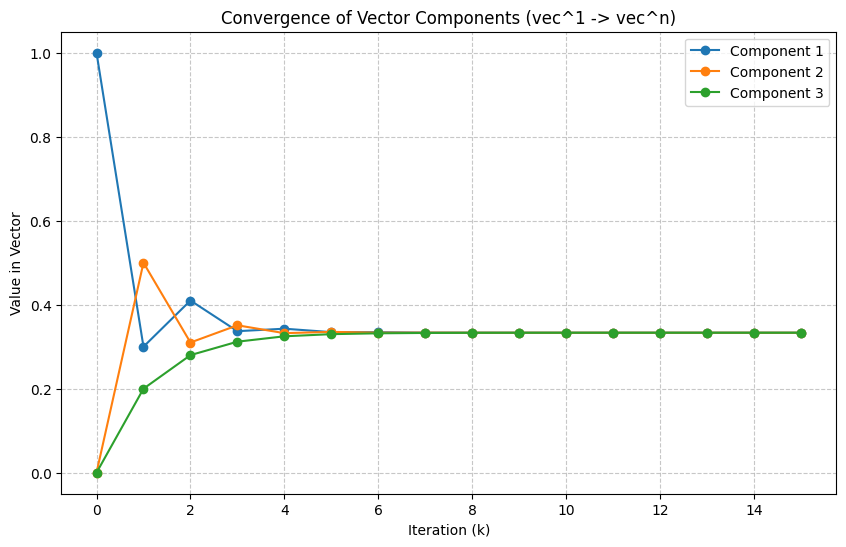

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# STEP 1: DEFINE THE MATRIX (M) AND INITIAL VECTOR (vec1)
# ==========================================
# Definition: The matrix M represents a linear transformation.
# For convergence to a steady state, we often use a Stochastic Matrix
# (where columns or rows sum to 1).

# Example 3x3 Matrix
M = np.array([
    [0.3, 0.6, 0.1],
    [0.5, 0.2, 0.3],
    [0.2, 0.2, 0.6]
])

# Initial Vector (vec1) - Starting with a random distribution
# Formula: v_initial = [x1, x2, ..., xn] where sum(xi) = 1
v = np.array([1.0, 0.0, 0.0])

# To store history for visualization
vec_history = [v.copy()]

# ==========================================
# STEP 2: THE ITERATION PROCESS (Repeated Multiplication)
# ==========================================
# Formula: vec_{k+1} = M * vec_k
# Definition: Power Iteration is the repeated application of a matrix
# to a vector to find the principal eigenvector (the direction of maximum "stretch").

num_iterations = 15
tolerance = 1e-6 # To stop if we converge early

print(f"{'Iteration':<12} | {'Vector State (vec^k)':<30}")
print("-" * 50)

for i in range(1, num_iterations + 1):
    prev_v = v.copy()

    # The actual Matrix-Vector multiplication
    # In Python/NumPy, '@' is the matrix multiplication operator
    v = M @ v

    # Step 2b: Normalization
    # Definition: To prevent values from becoming too large/small,
    # we normalize so the vector sum stays 1 (L1 Norm).
    v = v / np.sum(v)

    vec_history.append(v.copy())

    # Print the progress
    print(f"vec^{i:<10} | {v}")

    # Check for Convergence
    # Formula: ||v_k - v_{k-1}|| < epsilon
    if np.linalg.norm(v - prev_v) < tolerance:
        print(f"\nConverged early at iteration {i}!")
        break

# ==========================================
# STEP 3: VISUALIZING THE CONVERGENCE
# ==========================================
history_array = np.array(vec_history)

plt.figure(figsize=(10, 6))

# Plotting the components of the vector over time
for component in range(len(v)):
    plt.plot(history_array[:, component], marker='o', label=f'Component {component+1}')

plt.title("Convergence of Vector Components (vec^1 -> vec^n)")
plt.xlabel("Iteration (k)")
plt.ylabel("Value in Vector")
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

Mathematical Definitions within the Process

The Transformation ($M \cdot \vec{v}$):Every time you multiply, you are "shifting" the vector's importance according to the weights in the matrix. If $M$ is the PageRank matrix, this multiplication represents one "step" of users clicking links.

The Dominant Eigenvalue:According to the Perron-Frobenius Theorem, for a matrix like the one above (positive entries), there is a unique "largest" eigenvalue ($\lambda = 1$ for stochastic matrices). The vector we converge to is the corresponding eigenvector.

Convergence ($\vec{v} \approx M \vec{v}$):As shown in your image ($vec^3 \to vec^4 \dots$), the change between steps becomes smaller and smaller. When $M \vec{v} = \vec{v}$, the vector has reached a fixed point.

Why does this matter?
In your previous CODE of nodes A, B, C, D, E, the matrix $M$ is built from those links. This code is the literal calculation that happens "under the hood" to determine which node is the most important.

##Addition of Two Vectors

Big Vector: Magnitude=12.81, Angle=51.34°
Small Vector: Magnitude=1.12
Resultant:  Magnitude=13.83, Angle=49.40°
------------------------------
Observation: The angle only shifted by 1.94°


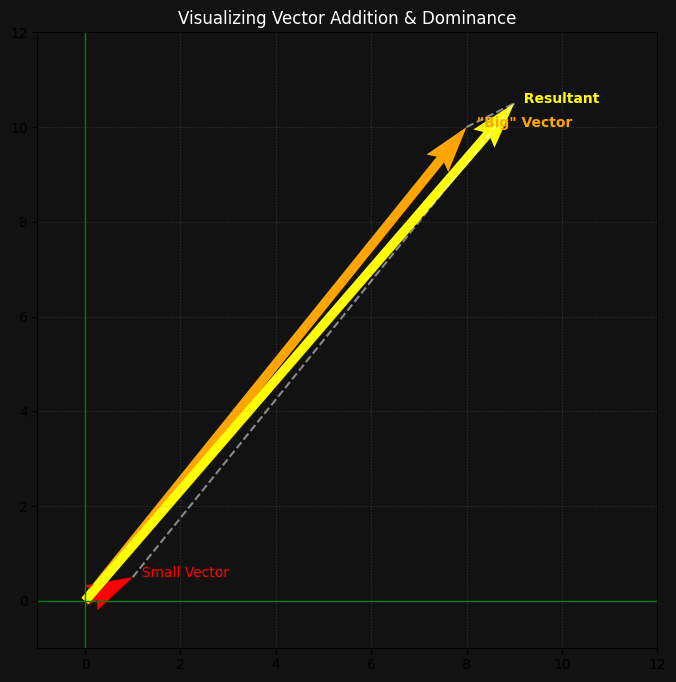

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# STEP 1: DEFINE THE VECTORS
# ==========================================
# Definition: A vector is an object with both magnitude (length) and direction.
# We represent them here as coordinates [x, y] in a 2D plane.

# The "Big" Vector
# Formula: Magnitude ||V|| = sqrt(x^2 + y^2)
v_big = np.array([8, 10])

# The "Small" Vector
# Note: We keep the values low so it doesn't shift the big vector much.
v_small = np.array([1, 0.5])

# ==========================================
# STEP 2: PERFORM VECTOR ADDITION
# ==========================================
# Formula: R = A + B
# Component-wise: Rx = Ax + Bx, Ry = Ay + By
# Definition: The resultant vector is the diagonal of the parallelogram
# formed by the two vectors starting from the same origin.

v_resultant = v_big + v_small

# ==========================================
# STEP 3: ANALYZE THE DOMINANCE
# ==========================================
def get_magnitude(v):
    return np.sqrt(np.sum(v**2))

def get_angle(v):
    # Definition: The direction of the vector in degrees relative to X-axis
    return np.degrees(np.arctan2(v[1], v[0]))

mag_big = get_magnitude(v_big)
mag_res = get_magnitude(v_resultant)
angle_big = get_angle(v_big)
angle_res = get_angle(v_resultant)

print(f"Big Vector: Magnitude={mag_big:.2f}, Angle={angle_big:.2f}°")
print(f"Small Vector: Magnitude={get_magnitude(v_small):.2f}")
print(f"Resultant:  Magnitude={mag_res:.2f}, Angle={angle_res:.2f}°")
print("-" * 30)
print(f"Observation: The angle only shifted by {abs(angle_res - angle_big):.2f}°")

# ==========================================
# STEP 4: VISUALIZATION
# ==========================================
plt.figure(figsize=(8, 8))

# Plotting vectors from the origin (0,0)
origin = np.array([[0, 0, 0], [0, 0, 0]]) # common origin for quiver

# quiver(X, Y, U, V) plots arrows from (X,Y) with components (U,V)
plt.quiver(*origin,
           [v_big[0], v_small[0], v_resultant[0]],
           [v_big[1], v_small[1], v_resultant[1]],
           color=['orange', 'red', 'yellow'],
           angles='xy', scale_units='xy', scale=1, width=0.015)

# Adding the 'tip-to-tail' dashed line to show addition
plt.plot([v_big[0], v_resultant[0]], [v_big[1], v_resultant[1]], 'w--', alpha=0.5)
plt.plot([v_small[0], v_resultant[0]], [v_small[1], v_resultant[1]], 'w--', alpha=0.5)

# Styling to match the "dark mode" blackboard style
plt.gca().set_facecolor('#121212')
plt.gcf().set_facecolor('#121212')
plt.axhline(0, color='green', linewidth=1)
plt.axvline(0, color='green', linewidth=1)

# Annotations
plt.text(v_big[0], v_big[1], '  "Big" Vector', color='orange', fontweight='bold')
plt.text(v_small[0], v_small[1], '  Small Vector', color='red')
plt.text(v_resultant[0], v_resultant[1], '  Resultant', color='yellow', fontweight='bold')

plt.xlim(-1, 12)
plt.ylim(-1, 12)
plt.title("Visualizing Vector Addition & Dominance", color='white')
plt.grid(color='gray', linestyle=':', alpha=0.3)
plt.show()

Key Takeaways from the Code:

Component-wise Addition: In Python, NumPy handles v_big + v_small by adding the corresponding $x$ values and $y$ values. This is much faster and cleaner than manual loops.

Angle Stability: Notice in the output that the Angle of the Resultant is very close to the Angle of the Big Vector. This proves the note in your image: "Resultant point is close to the 'big' vector."

Magnitude Impact: The magnitude of the resultant is not simply mag_big + mag_small. It follows the Law of Cosines, but since the vectors are mostly aligned in this example, it looks close to a simple sum.

##Combination of Power Iteration (the matrix flow) with the Vector Addition (the teleportation/damping factor) to create the full, robust PageRank algorithm used by search engines.

Iter  | Flow (Big V)    + Teleport (Small V) = Resultant
--------------------------------------------------------------------------------
1     | 0.1700 (avg)   + 0.0300 (const)      = 0.2000
2     | 0.1700 (avg)   + 0.0300 (const)      = 0.2000
3     | 0.1700 (avg)   + 0.0300 (const)      = 0.2000
4     | 0.1700 (avg)   + 0.0300 (const)      = 0.2000
5     | 0.1700 (avg)   + 0.0300 (const)      = 0.2000


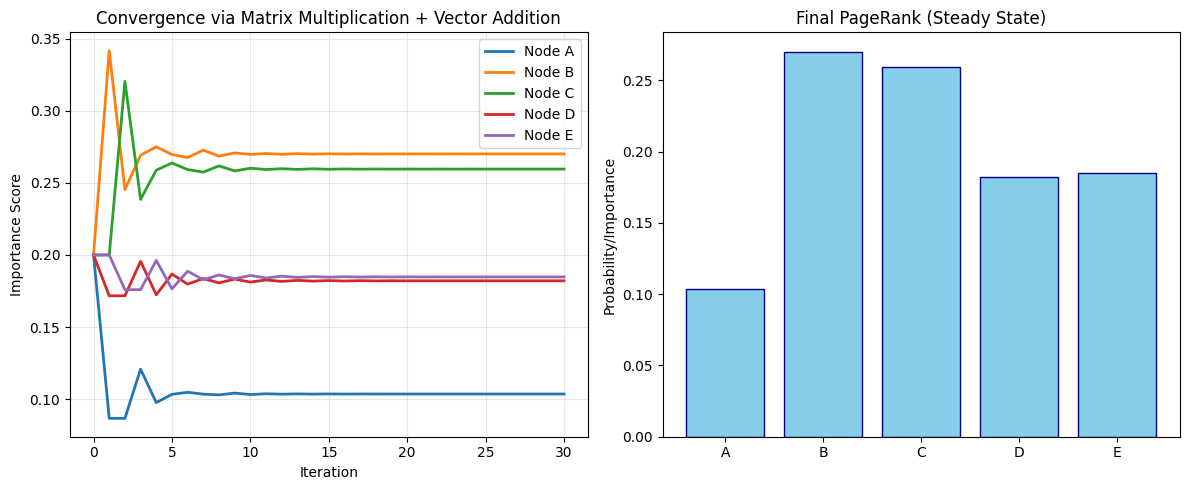

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

# ==========================================
# STEP 1: DEFINE THE GRAPH STRUCTURE (From Image 1)
# ==========================================
# We build the transition matrix M where M[j][i] is the probability
# of moving from node i to node j.

# Nodes: A=0, B=1, C=2, D=3, E=4
M = np.array([
    [0,   0,   1/3, 0,   0  ], # To A from C
    [1,   0,   1/3, 0,   1/2], # To B from A, C, E
    [0,   1,   0,   0,   0  ], # To C from B
    [0,   0,   1/3, 0,   1/2], # To D from C, E
    [0,   0,   0,   1,   0  ]  # To E from D
])

# ==========================================
# STEP 2: DEFINE THE DAMPING FACTOR (Concept of Addition)
# ==========================================
# Definition: The Damping Factor (d) represents the probability that
# a user follows links. (1-d) is the "teleportation" probability.
# Formula: V_new = d * (M * V_old) + (1-d) * (Teleportation_Vector)

d = 0.85  # Standard Google damping factor
n = 5     # Number of nodes
v = np.array([0.2, 0.2, 0.2, 0.2, 0.2]) # Initial uniform vector (from Image 1)

# The "Small Vector" that we add in every step for stability
# Definition: This is the vector addition concept from Image 3.
teleport_vector = np.ones(n) / n

# ==========================================
# STEP 3: REPEATED IMPROVEMENT (The Combined Loop)
# ==========================================
history = [v.copy()]
iterations = 30

print(f"{'Iter':<5} | {'Flow (Big V)':<15} + {'Teleport (Small V)':<18} = {'Resultant'}")
print("-" * 80)

for i in range(iterations):
    # Part A: The Power Iteration (The "Big Vector")
    # This is the matrix multiplication from Image 2
    graph_flow = M @ v

    # Part B: The Addition (The "Small Vector")
    # Applying the Concept from Image 3: Adding a small vector to a big one.
    v_new = (d * graph_flow) + ((1 - d) * teleport_vector)

    # Check for convergence
    if np.linalg.norm(v_new - v) < 1e-6:
        print(f"Converged at iteration {i}!")
        break

    v = v_new
    history.append(v.copy())

    if i < 5:
        # Visualizing the components of the addition in the first few steps
        print(f"{i+1:<5} | {np.mean(d*graph_flow):.4f} (avg)   + {np.mean((1-d)*teleport_vector):.4f} (const)      = {np.mean(v):.4f}")

# ==========================================
# STEP 4: VISUALIZATION OF RESULTS
# ==========================================
history = np.array(history)
plt.figure(figsize=(12, 5))

# Plotting convergence
plt.subplot(1, 2, 1)
for i, label in enumerate(['A', 'B', 'C', 'D', 'E']):
    plt.plot(history[:, i], label=f"Node {label}", linewidth=2)
plt.title("Convergence via Matrix Multiplication + Vector Addition")
plt.xlabel("Iteration")
plt.ylabel("Importance Score")
plt.legend()
plt.grid(True, alpha=0.3)

# Bar chart of final scores
plt.subplot(1, 2, 2)
final_scores = history[-1]
plt.bar(['A', 'B', 'C', 'D', 'E'], final_scores, color='skyblue', edgecolor='navy')
plt.title("Final PageRank (Steady State)")
plt.ylabel("Probability/Importance")

plt.tight_layout()
plt.show()

Connecting the Three Concepts

The Graph: Defined the "rules of the game" (our Matrix $M$). It dictates where the "wealth" flows.

Power Iteration: The loop M @ v. By repeating this multiplication, we allow the rank to flow through the network until it settles into its most natural distribution.

Vector Addition: The + (1-d) * teleport_vector. We saw that adding a small vector to a big one doesn't change the direction much, but it shifts the point.In PageRank, this "shift" prevents the rank from getting stuck in "Spider Traps" or "Dead Ends." Even if a node has no out-links, the small added vector gives every node a tiny bit of importance to keep the math working.


Final Result

You will notice that Node B and C dominate. This is because, they are at the center of the most loops.